In [1]:
import numpy as np

def generate_annulus_point_cloud(n, mean_radius=2.0, std_radius=0.3, noise_box=6.0, seed=None):
    """
    Generate a point cloud of n points consisting of:
    - 90% points sampled from a Gaussian annulus
    - 10% points sampled uniformly from a square
    
    Parameters:
        n (int): Total number of points
        mean_radius (float): Mean radius for annulus
        std_radius (float): Std deviation for annulus
        noise_box (float): Half side length of square [-noise_box, noise_box]^2
        seed (int or None): Random seed for reproducibility
        
    Returns:
        X (np.ndarray): Array of shape (n, 2)
    """
    if seed is not None:
        np.random.seed(seed)

    n_annulus = int(0.9 * n)
    n_noise = n - n_annulus

    # Sample annulus points
    radii = np.random.normal(loc=mean_radius, scale=std_radius, size=n_annulus)
    angles = np.random.uniform(low=0, high=2 * np.pi, size=n_annulus)
    x_annulus = np.stack((radii * np.cos(angles), radii * np.sin(angles)), axis=1)

    # Sample noise points
    x_noise = np.random.uniform(low=-noise_box, high=noise_box, size=(n_noise, 2))

    # Combine
    X = np.vstack((x_annulus, x_noise))
    return X

In [2]:
num_points = 1500
X = generate_annulus_point_cloud(num_points, seed=42)
# save as txt file with comma separated values and value is .5f
np.savetxt(f'data/PointCloud/annulus_{num_points}.txt', X, delimiter=',', fmt='%.5f')

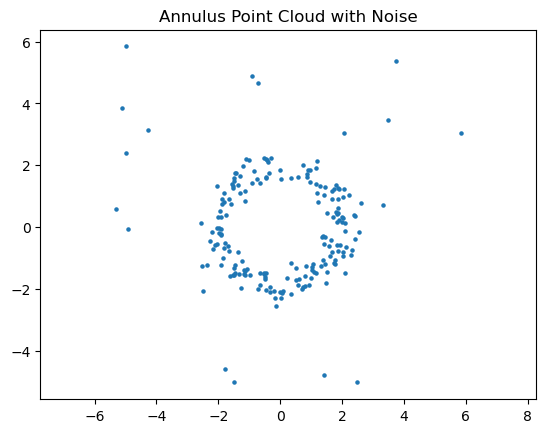

In [3]:
import matplotlib.pyplot as plt
num_points = 200
X = generate_annulus_point_cloud(num_points, seed=42)
plt.scatter(X[:, 0], X[:, 1], s=5)
plt.axis('equal')
plt.title("Annulus Point Cloud with Noise")
plt.show()

In [3]:
for num_points in [50, 100, 200, 400,  600, 800, 1000]:
    X = generate_annulus_point_cloud(num_points, seed=42)
    # save as txt file with comma separated values and value is .5f
    np.savetxt(f'data/PointCloud/annulus_{num_points}.txt', X, delimiter=',', fmt='%.5f')

## make_blobs

In [12]:
import numpy as np
from sklearn.datasets import make_blobs
from scipy.spatial.distance import pdist, squareform

# Generate 3 clusters in 3D
for num_points in [500, 600, 700, 800, 900, 1000]:
    points_blobs, labels_blobs = make_blobs(
        n_samples=num_points,
        centers=3,
        n_features=3,
        cluster_std=1.5,
        random_state=42
    )
    # save as txt file with comma separated values and value is .5f
    np.savetxt(f'data/PointCloud/blobs_{num_points}.txt', points_blobs, delimiter=',', fmt='%.5f')
# points_blobs is a (2000,3) NumPy array
# labels_blobs is an integer array of cluster assignments

# Pairwise Euclidean distance matrix
D_blobs = squareform(pdist(points_blobs))
print("blobs:", points_blobs.shape, "distance matrix:", D_blobs.shape)


blobs: (1000, 3) distance matrix: (1000, 1000)


In [11]:
# visualize the 3D points 
import plotly.graph_objects as go
import numpy as np

# Generate 3D points
points = points_blobs

# Create a 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=points[:, 0],
    y=points[:, 1],
    z=points[:, 2],
    mode='markers',
    marker=dict(
        size=5,
        color=labels_blobs,
        colorscale='Viridis',
        opacity=0.8
    )
)])
fig.show()